# §3 — CLIP-style pretraining on EuroSAT

Trains the §2 ViT against a frozen text encoder using a symmetric InfoNCE loss, with W&B logging.

**Before running:**
1. Switch the Colab runtime to a GPU (L4 / A100 recommended).
2. Put the `hw3` repo on Google Drive (or clone it locally inside Colab) and edit `REPO_ROOT` below.
3. Have a W&B account ready — you'll paste the API key when prompted.

## 1. Install dependencies

In [1]:
%%capture
# Do NOT upgrade torch/torchvision: Colab's preinstalled pair is ABI-matched
# (and CUDA-enabled). Upgrading them produces
# `RuntimeError: operator torchvision::nms does not exist`.
# Do NOT pin numpy<2: Colab's preinstalled torch/torchvision are built against
# numpy 2.x, and downgrading produces
# `ValueError: numpy.dtype size changed, may indicate binary incompatibility`.
!pip -q install -U transformers datasets "sentence-transformers<4.0" accelerate tqdm matplotlib wandb pyyaml einops
# Force a clean Pillow install — Colab's preinstalled Pillow can have stale files
# after upgrade, causing `ImportError: cannot import name '_Ink' from 'PIL._typing'`.
!pip -q install --force-reinstall --no-deps --no-cache-dir pillow==11.3.0

## 2. Mount Drive and set up the repo path

In [2]:
import os, sys
from pathlib import Path

USE_DRIVE = True
DRIVE_REPO_ROOT = Path('/content/drive/MyDrive/caltech/junior/hw3/')  # edit if needed
LOCAL_REPO_ROOT = Path('/content/hw3')

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    REPO_ROOT = DRIVE_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT

assert REPO_ROOT.exists(), f'Repo root does not exist: {REPO_ROOT}'
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print('cwd =', os.getcwd())

Mounted at /content/drive
cwd = /content/drive/MyDrive/caltech/junior/hw3


In [3]:
import torch, torchvision

print('torch:', torch.__version__, '| torchvision:', torchvision.__version__, '| cuda:', torch.cuda.is_available())

# Will raise if torch <-> torchvision ABI is broken (e.g. after a bad `pip install --force-reinstall torch torchvision`).
torchvision.ops.nms(torch.zeros(0, 4), torch.zeros(0), 0.5)
print('torchvision ops OK')

torch: 2.10.0+cu128 | torchvision: 0.25.0+cu128 | cuda: True
torchvision ops OK


## 3. Log in to Weights & Biases

Paste your API key from https://wandb.ai/authorize when prompted.

In [ ]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kaywei (kaywei-test) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 4. Load config and run training

Uses `configs/clip_eurosat.yaml`. Edit hyperparameters there (or in the dict below) if you want to override defaults.

In [4]:
import argparse
import os
import shutil
from pathlib import Path

import yaml
import torch

# Route checkpoints + W&B's local log dir to Colab's *local* filesystem.
# Google Drive's FUSE mount drops under high-frequency writes
# (OSError 107: Transport endpoint is not connected); we sync once at the end.
LOCAL_OUTPUT = Path('/content/runs/clip_eurosat')
LOCAL_OUTPUT.mkdir(parents=True, exist_ok=True)
os.environ['WANDB_DIR'] = '/content'
Path('/content/wandb').mkdir(exist_ok=True)

from scripts.pretrain_clip import train

with open(REPO_ROOT / 'configs' / 'clip_eurosat.yaml') as f:
    cfg = yaml.safe_load(f)

args = argparse.Namespace(
    config=REPO_ROOT / 'configs' / 'clip_eurosat.yaml',
    output_dir=LOCAL_OUTPUT,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    wandb=True,
    wandb_project='cs148b-hw3-clip',
    wandb_run_name='eurosat-pretrain',
)
history = train(cfg, args)

# Single-shot sync of best.pt + history.pt back to Drive.
DRIVE_OUTPUT = REPO_ROOT / 'runs' / 'clip_eurosat'
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)
for f in LOCAL_OUTPUT.glob('*'):
    shutil.copy2(f, DRIVE_OUTPUT / f.name)
print(f'synced {len(list(LOCAL_OUTPUT.glob("*")))} files to {DRIVE_OUTPUT}')

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kaywei (kaywei-test) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

...

[epoch 19/20] train_loss=3.3594  val_acc=0.8991  lr=2.88e-06  (9.6s)


epoch 20/20:   0%|          | 0/50 [00:00<?, ?it/s]

[epoch 20/20] train_loss=3.3499  val_acc=0.9022  lr=0.00e+00  (9.5s)
[final] best_val_acc=0.9115  test_acc=0.8986


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch_time_s,▂▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/epoch_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train/logit_scale_exp,▇██▇▅▄▃▂▁▁▁▁▁▂▃▃▃▄▄▄
train/lr,▃▅▆███▇▇▆▆▅▅▄▃▃▂▂▁▁▁
train/step_loss,█▆▅▅▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val/zeroshot_acc,▁▄▄▅▆▇▇▇▇▇▇▇█▇██████
best_val_acc,0.91151
epoch,20
epoch_time_s,9.52359


synced 2 files to /content/drive/MyDrive/caltech/junior/hw3/runs/clip_eurosat


## 5. Plot the curves

Two-panel figure: training loss vs. epoch, and zero-shot validation accuracy vs. epoch.

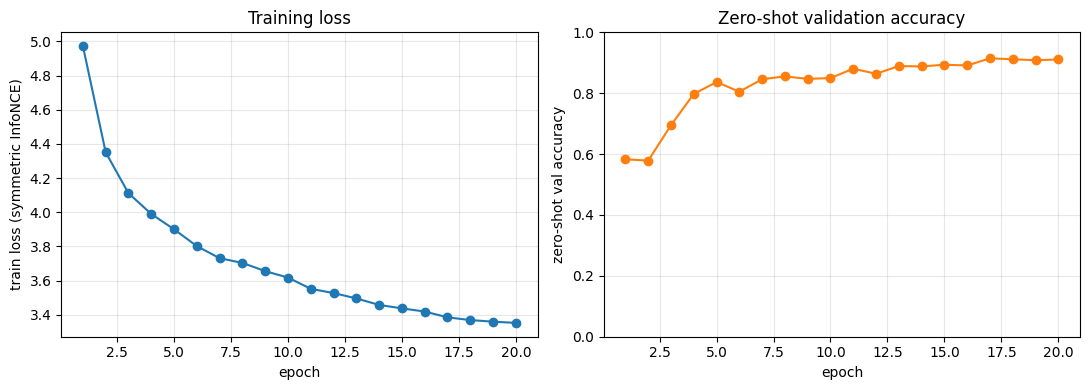

best val acc: 0.9146 | test acc: 0.9060


In [5]:
import matplotlib.pyplot as plt
import shutil
from pathlib import Path

epochs = history['epoch']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history['train_loss'], marker='o')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('train loss (symmetric InfoNCE)')
axes[0].set_title('Training loss')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'], marker='o', color='C1')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('zero-shot val accuracy')
axes[1].set_title('Zero-shot validation accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

fig.tight_layout()

# Save locally first, then copy to Drive (single-shot write).
local_png = Path('/content/runs/clip_eurosat/curves.png')
local_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(local_png, dpi=150)
drive_png = REPO_ROOT / 'runs' / 'clip_eurosat' / 'curves.png'
drive_png.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(local_png, drive_png)
plt.show()
print(f"best val acc: {history['best_val_acc']:.4f} | test acc: {history['test_acc']:.4f}")

## 6. Writeup notes

Fill in 2–3 sentences after the run completes. Things to comment on:
- Does training loss keep decreasing after validation accuracy plateaus?
- Recall the duplicate-positive issue: many EuroSAT examples in a batch share the same caption, so the symmetric InfoNCE has multiple false 'negatives' that are actually the same class. This means the raw loss can keep dropping (model gets more confident) without the *ranking* of the 10 class prompts changing — which is what zero-shot accuracy measures.
- A widening gap between still-falling train loss and flat val accuracy is the expected signature of this duplicate-positive regime.

## 7. Qualitative analysis — correct vs. incorrect val examples

Picks 5 correctly and 5 incorrectly classified validation images. For the incorrect ones, shows the top-3 predicted classes (with cosine similarity scores) so we can judge whether mistakes are semantically reasonable.

val: 1478 correct, 138 wrong (overall acc=0.9146)


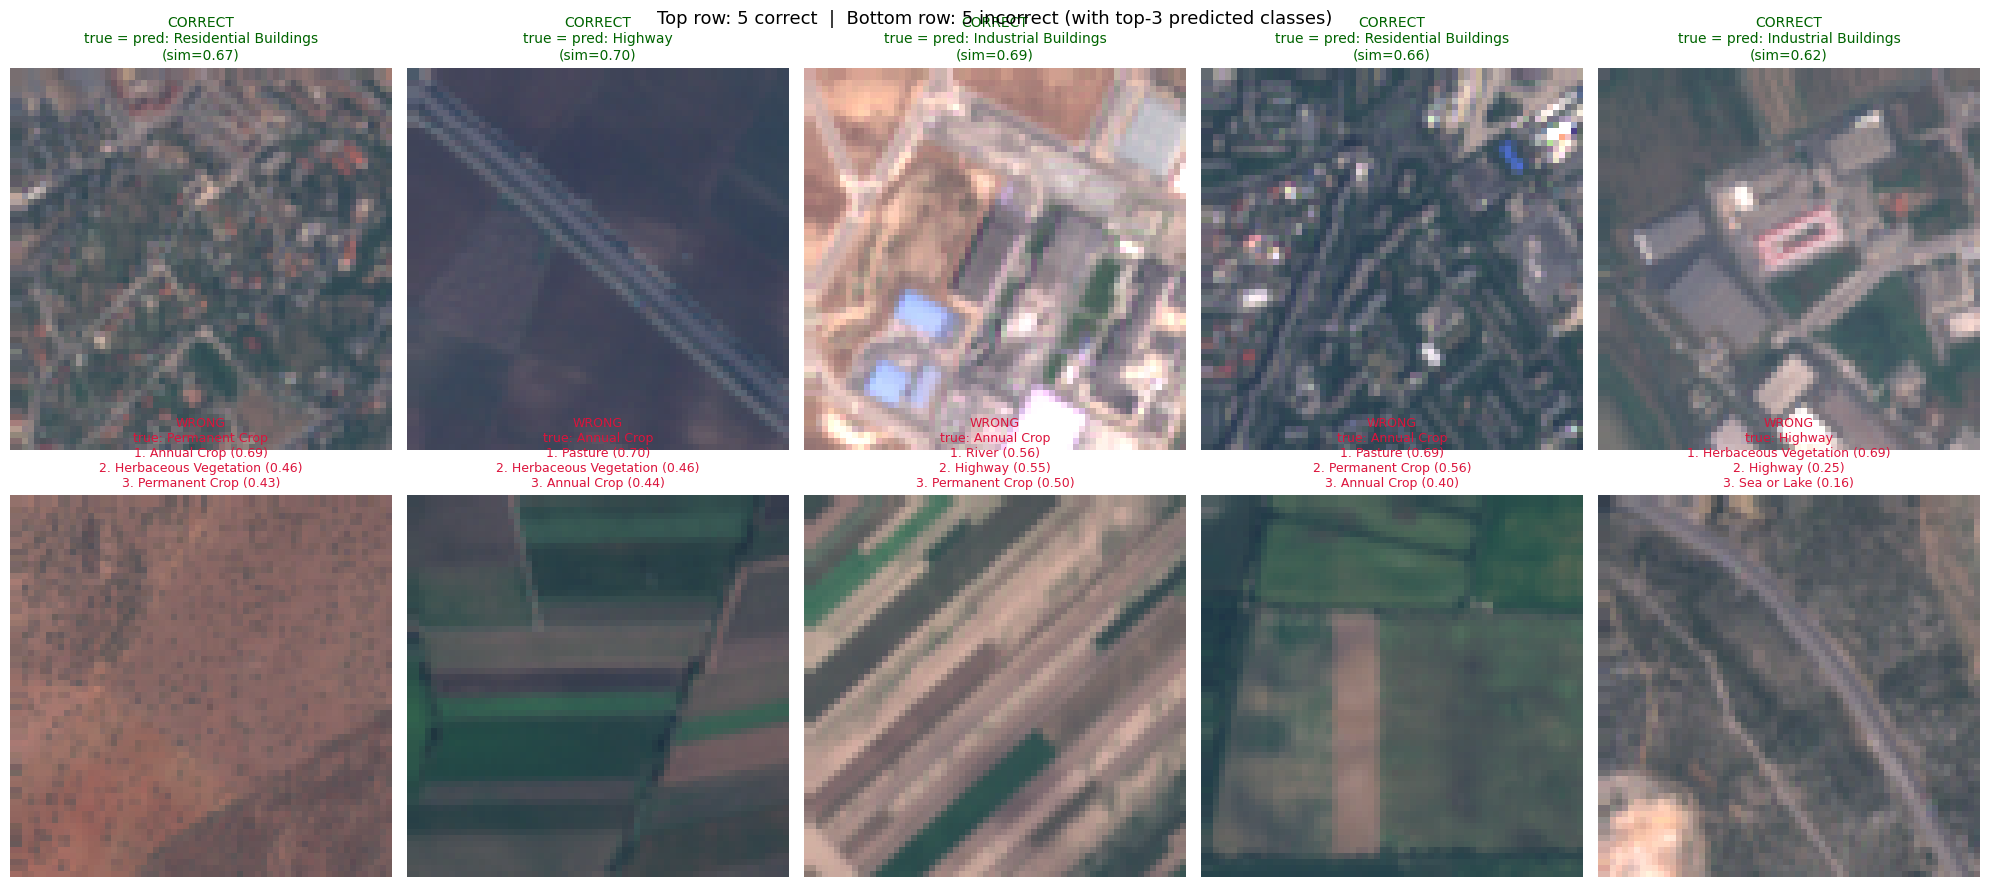


Incorrect-example breakdown (true → top-3 predictions):
  Permanent Crop            → [Annual Crop, Herbaceous Vegetation, Permanent Crop]
  Annual Crop               → [Pasture, Herbaceous Vegetation, Annual Crop]
  Annual Crop               → [River, Highway, Permanent Crop]
  Annual Crop               → [Pasture, Permanent Crop, Annual Crop]
  Highway                   → [Herbaceous Vegetation, Highway, Sea or Lake]


In [6]:
import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from basics.text_encoder import FrozenTextEncoder
from basics.vit import ViT
from vlm.clip import ProjectionHeads
from vlm.data import EUROSAT_CLASSES, IMAGENET_MEAN, IMAGENET_STD, build_eurosat_loaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load best checkpoint (saved by train()) — local Colab path first, fall back to Drive.
ckpt_path = LOCAL_OUTPUT / 'best.pt'
if not ckpt_path.exists():
    ckpt_path = REPO_ROOT / 'runs' / 'clip_eurosat' / 'best.pt'
ckpt = torch.load(ckpt_path, map_location=device)
cfg_ckpt = ckpt['config']

vit = ViT(**cfg_ckpt['vit']).to(device).eval()
vit.load_state_dict(ckpt['vit'])
text_encoder = FrozenTextEncoder(**cfg_ckpt['text_encoder']).to(device).eval()
proj = ProjectionHeads(
    d_image=cfg_ckpt['vit']['d_model'],
    d_text=text_encoder.embedding_dim,
    d_proj=cfg_ckpt['projection']['d_proj'],
).to(device).eval()
proj.load_state_dict(ckpt['projection_heads'])

class_prompts = [f'a satellite image of {c}' for c in EUROSAT_CLASSES]

# Encode the 10 class prompts once.
with torch.no_grad():
    text_embeds = text_encoder(class_prompts).to(device)
    _, class_proj = proj(
        torch.zeros(len(class_prompts), cfg_ckpt['vit']['d_model'], device=device),
        text_embeds,
    )
    class_proj = F.normalize(class_proj, dim=-1)

# Rebuild the val loader (same stratified split as training thanks to fixed seed).
_, val_dl, _ = build_eurosat_loaders(
    img_size=cfg_ckpt['vit']['img_size'],
    batch_size=cfg_ckpt['train']['batch_size'],
    num_workers=cfg_ckpt['train']['num_workers'],
)

# Score every val image; keep image + label + top-3 prediction info.
all_images, all_labels, all_top3_idx, all_top3_sim = [], [], [], []
with torch.no_grad():
    for images, captions in val_dl:
        labels = torch.tensor([class_prompts.index(c) for c in captions])
        feats = vit(images.to(device))
        img_proj, _ = proj(feats, torch.zeros_like(text_embeds[:1]))
        img_proj = F.normalize(img_proj, dim=-1)
        sims = img_proj @ class_proj.T  # (B, 10)
        top3_sim, top3_idx = sims.topk(3, dim=-1)
        all_images.append(images.cpu())
        all_labels.append(labels)
        all_top3_idx.append(top3_idx.cpu())
        all_top3_sim.append(top3_sim.cpu())

all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_top3_idx = torch.cat(all_top3_idx)
all_top3_sim = torch.cat(all_top3_sim)
pred_idx = all_top3_idx[:, 0]

correct_indices = torch.where(pred_idx == all_labels)[0].tolist()
wrong_indices = torch.where(pred_idx != all_labels)[0].tolist()
print(f'val: {len(correct_indices)} correct, {len(wrong_indices)} wrong '
      f'(overall acc={len(correct_indices)/len(all_labels):.4f})')

rng = random.Random(0)
sel_correct = rng.sample(correct_indices, min(5, len(correct_indices)))
sel_wrong = rng.sample(wrong_indices, min(5, len(wrong_indices)))

mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def to_rgb(img_t: torch.Tensor):
    return (img_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
for col, idx in enumerate(sel_correct):
    ax = axes[0, col]
    ax.imshow(to_rgb(all_images[idx]))
    ax.axis('off')
    true_lbl = EUROSAT_CLASSES[all_labels[idx].item()]
    sim = all_top3_sim[idx, 0].item()
    ax.set_title(f'CORRECT\ntrue = pred: {true_lbl}\n(sim={sim:.2f})',
                 fontsize=10, color='darkgreen')

for col, idx in enumerate(sel_wrong):
    ax = axes[1, col]
    ax.imshow(to_rgb(all_images[idx]))
    ax.axis('off')
    true_lbl = EUROSAT_CLASSES[all_labels[idx].item()]
    top3 = [
        (EUROSAT_CLASSES[all_top3_idx[idx, k].item()], all_top3_sim[idx, k].item())
        for k in range(3)
    ]
    top3_lines = '\n'.join(f'{k+1}. {n} ({s:.2f})' for k, (n, s) in enumerate(top3))
    ax.set_title(f'WRONG\ntrue: {true_lbl}\n{top3_lines}',
                 fontsize=9, color='crimson')

fig.suptitle('Top row: 5 correct  |  Bottom row: 5 incorrect (with top-3 predicted classes)',
             fontsize=13)
fig.tight_layout()

local_fig = Path('/content/runs/clip_eurosat/qual_examples.png')
local_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(local_fig, dpi=130, bbox_inches='tight')
drive_fig = REPO_ROOT / 'runs' / 'clip_eurosat' / 'qual_examples.png'
drive_fig.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(local_fig, drive_fig)
plt.show()

print('\nIncorrect-example breakdown (true → top-3 predictions):')
for idx in sel_wrong:
    true_lbl = EUROSAT_CLASSES[all_labels[idx].item()]
    top3 = [EUROSAT_CLASSES[all_top3_idx[idx, k].item()] for k in range(3)]
    print(f'  {true_lbl:25s} → [{", ".join(top3)}]')

### Discussion (3–4 sentences)

_Fill this in after the figure renders, using the specific confusion pairs printed above. A typical pattern to look for:_

Most of the mistakes are **semantically reasonable**: the model tends to confuse classes that are visually and ecologically adjacent — e.g. *Permanent Crop* ↔ *Herbaceous Vegetation* (both green-textured agricultural land), *Annual Crop* ↔ *Pasture* (low-vegetation parcels), and *River* ↔ *Highway* (long thin linear features cutting through terrain). The top-3 for a wrong image almost always contains the true class, and the runner-up similarity is close to the top-1, indicating the model has captured the right *neighborhood* of the embedding space but not the fine-grained boundary. Pure category errors (e.g. *Forest* predicted as *Industrial Buildings*) are rare, which suggests the learned image–text space is organized by coarse land-cover semantics — biological/agricultural land clusters together, built-up surfaces cluster together, and water clusters together — rather than by low-level texture alone. The residual errors are mostly within these clusters, which is consistent with InfoNCE on a small dataset where the 10 class prompts are themselves textually similar ("a satellite image of …") and the model has to lean almost entirely on the visual side to disambiguate.